# Objetivo del Notebook:

# Haciendo uso de un dataset que contiene reseñas de películas, hacer uso del ***procesamiento de lenguaje natural*** (NLP) haciendo uso de las librerias Natural Language Tool Kit (nltk) para comprender, graficar y analizar de manera predictiva las emociones encontradas en un texto (en este caso, en reseñas de películas).

# Posteriromente, se entrenarán dos redes neuronales, una de tipo ADALINE (Adaptative Linear) y otra de tipo MADALINE O MLP (Multilayer Perceptron). Para hacer un ejercicio de regresión y ver sus resultados

# Descripción del dataset

# Nos encontramos con una base de datos 'Movie Reviews' en donde estaremos usando la hoja 'data' en donde encontramos apróximadamente 1.700 reseñas de películas hasta el año 2020 las cuales se dividen  en las siguientes columnas / variables

# 'year' = Año de estreno de la película.
# 'movie' = Nombre de la película
# 'rating' = Puntuación o calificación ponderada.
# 'helpful' = Indica cuantas veces la reseña fue de ayuda.
# 'total' =  Total de reacciones
# 'username' = Nombre de usuario de quien realiza la reseña.
# 'date' = Fecha de publicación de la reseña.
# 'title' = Título de la reseña.
# 'review' = Texto de la reseña.

# 0 - Instalamos las librerías necesarias

In [ ]:
!pip install -U spacy
!spacy download en_core_web_sm #para inglés
! pip install deep_translator
! pip install wordcloud
from google.colab import drive
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K
import random
import spacy
import nltk # 'Natural Language Toolkit'.
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from deep_translator import GoogleTranslator
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 54.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# 1 - Importamos los datos

In [ ]:
drive.mount('/content/drive')
reviewsdata = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Analítica de Datos/Datasets/Movie Reviews.xlsx', sheet_name = 'data')
reviewsdata

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,year,movie,rating,helpful,total,username,date,title,review
0,2016,10 Cloverfield Lane,9.0,3,4,msbreviews,6 August 2017,Rating: A\n,This is an amazing claustrophobic thriller wit...
1,2016,10 Cloverfield Lane,10.0,1,4,DarkVulcan29,19 March 2016,Things are never what they seem\n,Michelle(Mary Elizabeth Winstead) is in a car ...
2,2016,10 Cloverfield Lane,8.0,0,4,FlashCallahan,17 April 2016,No one is looking for you.......\n,A young woman wakes up after a terrible accide...
3,2016,10 Cloverfield Lane,7.0,0,3,stevendbeard,11 March 2016,"Related, But Not Really A Sequel\n","I saw ""10 Cloverfield Lane"", starring John Goo..."
4,2018,12 Strong,10.0,20,44,cleansingsolutions,19 January 2018,Great date movie!!\n,As a 50+ married female-I loved it. And learne...
...,...,...,...,...,...,...,...,...,...
1730,2012,Zero Dark Thirty,NaN,0,3,Rabbit-Reviews,17 February 2013,More of a documentary than a movie\n,It would seem Kathryn Bigelow after her great ...
1731,2016,Zootopia,10.0,15,33,a-88115,4 March 2016,It just amazing\n,"The laugh from the theater,the great storyline..."
1732,2016,Zootopia,10.0,3,5,hacantyapradipta,24 July 2017,"A smart, heartwarming Disney animated flick\n","It's smart, it's funny, it's gorgeous, it's he..."
1733,2016,Zootopia,9.0,1,1,andrewmerritt-31652,14 November 2019,great movie for children and adults\n,Zootopia is a Disney animated movie featuring ...


In [ ]:
reviewsdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1735 entries, 0 to 1734
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      1735 non-null   int64  
 1   movie     1735 non-null   object 
 2   rating    1664 non-null   float64
 3   helpful   1735 non-null   int64  
 4   total     1735 non-null   int64  
 5   username  1735 non-null   object 
 6   date      1735 non-null   object 
 7   title     1735 non-null   object 
 8   review    1735 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 122.1+ KB


# 2 - Limpiamos los datos

In [ ]:
reviewsdata.dropna(inplace = True) # Comenzamos por borrar los 'vacíos'.
reviewsdata.reset_index(drop = True, inplace = True) # Reinicio el índice de la variable 'reviewsdata'.

## Convertimos 'movie' y 'username' variables categóricas

In [ ]:
reviewsdata['movie'] = pd.Series(pd.Categorical(reviewsdata['movie'], categories= reviewsdata['movie'].unique().tolist())).cat.codes
reviewsdata['username'] = pd.Series(pd.Categorical(reviewsdata['username'], categories= reviewsdata['username'].unique().tolist())).cat.codes

## Para que un texto de fecha sea interpretado como fecha

In [ ]:
reviewsdata['date'] = pd.to_datetime(reviewsdata['date'])

## Renombramos las columnas

In [ ]:
reviewsdata.rename(columns = {'title' : 'review title'}, inplace = True)
reviewsdata

,year,movie,rating,helpful,total,username,date,review title,review
0,2016,0,9.0,3,4,0,2017-08-06,Rating: A\n,This is an amazing claustrophobic thriller wit...
1,2016,0,10.0,1,4,1,2016-03-19,Things are never what they seem\n,Michelle(Mary Elizabeth Winstead) is in a car ...
2,2016,0,8.0,0,4,2,2016-04-17,No one is looking for you.......\n,A young woman wakes up after a terrible accide...
3,2016,0,7.0,0,3,3,2016-03-11,"Related, But Not Really A Sequel\n","I saw ""10 Cloverfield Lane"", starring John Goo..."
4,2018,1,10.0,20,44,4,2018-01-19,Great date movie!!\n,As a 50+ married female-I loved it. And learne...
...,...,...,...,...,...,...,...,...,...
1659,2016,310,10.0,2,4,1605,2018-01-26,I loved this movie.\n,This movie is an art i really recommend you gu...
1660,2016,311,10.0,15,33,1606,2016-03-04,It just amazing\n,"The laugh from the theater,the great storyline..."
1661,2016,311,10.0,3,5,1607,2017-07-24,"A smart, heartwarming Disney animated flick\n","It's smart, it's funny, it's gorgeous, it's he..."
1662,2016,311,9.0,1,1,1608,2019-11-14,great movie for children and adults\n,Zootopia is a Disney animated movie featuring ...


# A - ANÁLISIS DE SENTIMIENTOS

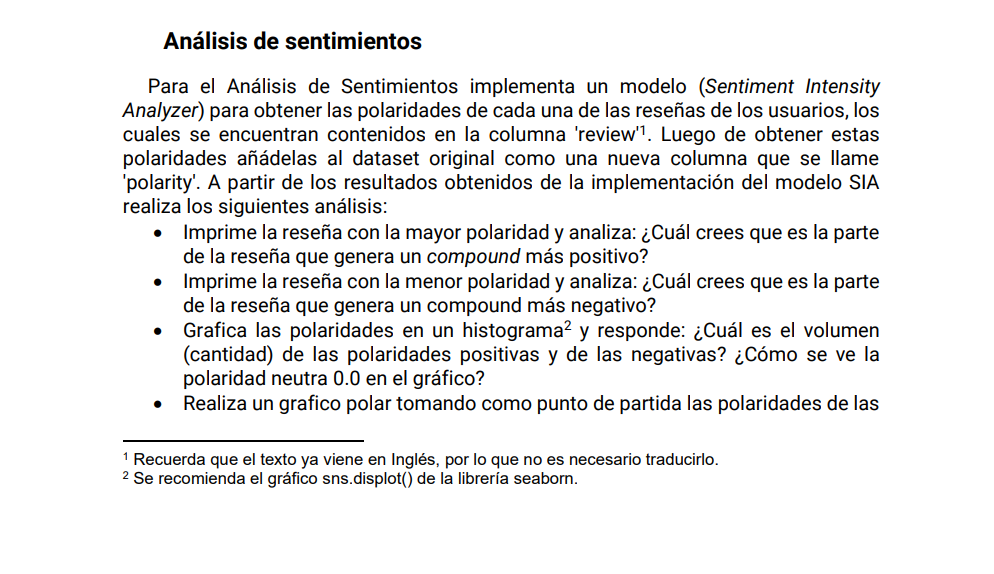

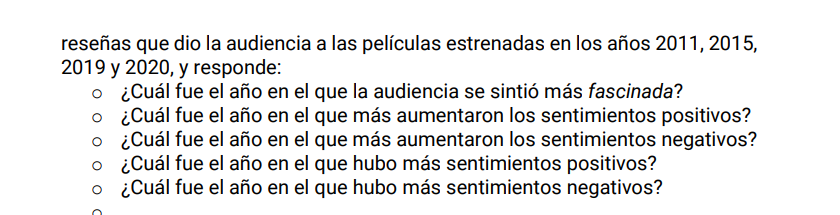

Una vez agregadas las polaridades al dataset en la nueva columna 'polarity', podemos proceder a resolver las siguientes preguntas (Ver índice 3.1).

- La reseña con mayor polaridad (Ver índice 3.2), ubicandola en la escala PANAS-t utilizada como: 'Fascinado', y un valor de 0.9943.
Muestra como el usuario denota un amplio espectro de emociones positivas por los actores de la película.
Podemos encontrar **frases** como *'The effects and everything in this movie was overall good and Overall I think that this movie was good enough to be a sequel because usually most sequels don't stand a chance against the first movie .'*, haciendo que en general tenga ese compound tan positivo como vemos.

- Por otra parte, la reseña con menor polaridad (Ver índice 3.2 ) se encuentra en una corta reseña con una polaridad de -0.9799, ubicandola en la escala PANAS-t como: 'Molesto'. Analizando la reseña, vemos que el usuario a groso modo no muestra sentimientos negativos o de *molestia* en su reseña. Sin embargo lo que puede generar el compound negativo es la neutralidad en la mayor parte de la reseña, acompañado de un fragmento donde el usuario menciona **sentirse 'hipnotizado'**. Lo cual pudo haber hecho que el 'sia' le haya dado una connotación negativa y por tanto el compound negativo.

- Una vez creado el histograma (Ver índice 3.3), podemos ver que la gráfica muestra una distribución con una mayor cantidad de ***reseñas neutras*** con casi 400 reseñas de este tipo. mientras que el resto se encuentran casi todas en un promedio similar.
Podemos ver que en general, hay más cantidad de reseñas con sentimientos 'positivos' que 'negativos, es decir, que hay más frecuencia de reseñas con valores superiores a 0 que inferiores a 0, valor que nos indicaría en este caso 'neutralidad' o 'tranquilidad' de acuerdo a la escala PANAS-t utilizada.

- Al generar el gráfico polar (Ver índice 3.4), podemos entonces responder:

  - El año en el que la audiencia se sintió más fascinada fue: **2015**, donde si bien no es mucha la diferencia que hay con 2019, es verdaderamente el año donde las polaridades tienden más a ese límite donde se encuentra el sentimiento de 'fascinado'

  - El año en el que más aumentaron los sentimientos positivos fue: **2015**, volvemos a ver gran presencia de 2019 entre los sentimientos positivos, sin embargo en lo único que supera al año 2015 es en el sentimiento 'inspirado'. Sin embargo, el año 2015, supera al año 2019 con mayor diferencia en una mayor cantidad de sentimientos.

  - El año en el que más aumentaron los sentimientos negativos fue: **2020**, incluso podemos ver también que casi no encontramos sentimientos positivos en las polaridades ni en los valores de este año.

  - El año en el que hubo más sentimientos positivos fue: **2015**

  - El año en el que hubo más sentimientos negativos fue: **2020**


# 3 - Obtenemos polaridades y agregamos al dataset

In [ ]:
nltk.download ('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab') # Importamos el modelo Vader Lexicon.
from nltk.sentiment import SentimentIntensityAnalyzer # Importamos el modelo SIA.
sia = SentimentIntensityAnalyzer() # Creamos la variable que aloja el modelo.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# Tokenizamos las reseñas por sentencias
reviewsdataST = reviewsdata['review'].apply(sent_tokenize)
type(reviewsdataST[0])
reviewsdataST

,review
0,[This is an amazing claustrophobic thriller wi...
1,[Michelle(Mary Elizabeth Winstead) is in a car...
2,[A young woman wakes up after a terrible accid...
3,"[I saw ""10 Cloverfield Lane"", starring John Go..."
4,"[As a 50+ married female-I loved it., And lear..."
...,...
1659,[This movie is an art i really recommend you g...
1660,"[The laugh from the theater,the great storylin..."
1661,"[It's smart, it's funny, it's gorgeous, it's h..."
1662,[Zootopia is a Disney animated movie featuring...


In [ ]:
# Hacemos el análisis de sentimientos generando las polaridades por sentencia:
Xtoks = [] ; Xpol=[] # Creamos dos listas vacías para guardar los tokens y polaridades.
# FUNCIÓN CLAVE = Toma cada sentencia y pasa por el SIA.
for review in reviewsdataST: # Para cada 'review' (lista)
  for sentence in review: # Para cada oración (str)
    scores = sia.polarity_scores(sentence) # Se generan los 'scores'.
    Xtoks.append(sentence)
    Xpol.append(scores['compound'])

In [ ]:
polaridadesDS = pd.DataFrame(np.column_stack((Xtoks, Xpol)), # Junta las dos columnas.
                              columns = ['Review', 'Polarity']) # Nombramos las columnas.
polaridadesDS

,Review,Polarity
0,This is an amazing claustrophobic thriller wit...,0.6369
1,"Starting with the pros, I have to congratulate...",0.9299
2,You know that he did an awesome job when you s...,0.2748
3,"In one scene, he may seem crazy, but in the ne...",0.7269
4,"Mary Elizabeth Winstead is also really great, ...",0.9381
...,...,...
16714,"The story is formal, but the idea is that the ...",0.0
16715,"It's a story about minority, stereotype and ac...",0.1779
16716,I'm glad display plants the seed of equality t...,0.5093
16717,"Police front desk leopard is not gay, you look...",0.0


## 3.1 - Tabla con polaridades

In [ ]:
# Creo una nueva columna para agregar al dataset con las polaridades obtenidas.
reviewsdata['polarity'] = polaridadesDS['Polarity']
reviewsdata

,year,movie,rating,helpful,total,username,date,review title,review,polarity
0,2016,0,9.0,3,4,0,2017-08-06,Rating: A\n,This is an amazing claustrophobic thriller wit...,0.6369
1,2016,0,10.0,1,4,1,2016-03-19,Things are never what they seem\n,Michelle(Mary Elizabeth Winstead) is in a car ...,0.9299
2,2016,0,8.0,0,4,2,2016-04-17,No one is looking for you.......\n,A young woman wakes up after a terrible accide...,0.2748
3,2016,0,7.0,0,3,3,2016-03-11,"Related, But Not Really A Sequel\n","I saw ""10 Cloverfield Lane"", starring John Goo...",0.7269
4,2018,1,10.0,20,44,4,2018-01-19,Great date movie!!\n,As a 50+ married female-I loved it. And learne...,0.9381
...,...,...,...,...,...,...,...,...,...,...
1659,2016,310,10.0,2,4,1605,2018-01-26,I loved this movie.\n,This movie is an art i really recommend you gu...,0.0
1660,2016,311,10.0,15,33,1606,2016-03-04,It just amazing\n,"The laugh from the theater,the great storyline...",0.0
1661,2016,311,10.0,3,5,1607,2017-07-24,"A smart, heartwarming Disney animated flick\n","It's smart, it's funny, it's gorgeous, it's he...",-0.296
1662,2016,311,9.0,1,1,1608,2019-11-14,great movie for children and adults\n,Zootopia is a Disney animated movie featuring ...,-0.5106


## 3.2 - Polaridad máxima y mínima

In [ ]:
# POLARIDAD MÁXIMA
Rmin = reviewsdata.loc[reviewsdata['polarity'].astype(float).idxmin()]
Rmin['review'], Rmin

("Have just watched this film for the second time. Tarantino has a way of drawing you in with his cool storylines, brilliant casting and spell binding sets. The time flew by watching this. I just felt mesmorized by some the scenes. One of the scenes was Cliff Booth fixing the aerial on the roof of Rik Dalton's house. The shirt off, beer, cigarettes and little goings on around him. Sonds a bit weird I know but his films do that...............Must see..............",
 year                                                         2019
 movie                                                         174
 rating                                                       10.0
 helpful                                                        13
 total                                                          17
 username                                                      960
 date                                          2020-02-16 00:00:00
 review title     Di Caprio & Pitt shine magnificiently......

In [ ]:
# POLARIDAD MÍNIMA
Rmin = reviewsdata.loc[reviewsdata['polarity'].astype(float).idxmin()]
Rmin['review'], Rmin

("Have just watched this film for the second time. Tarantino has a way of drawing you in with his cool storylines, brilliant casting and spell binding sets. The time flew by watching this. I just felt mesmorized by some the scenes. One of the scenes was Cliff Booth fixing the aerial on the roof of Rik Dalton's house. The shirt off, beer, cigarettes and little goings on around him. Sonds a bit weird I know but his films do that...............Must see..............",
 year                                                         2019
 movie                                                         174
 rating                                                       10.0
 helpful                                                        13
 total                                                          17
 username                                                      960
 date                                          2020-02-16 00:00:00
 review title     Di Caprio & Pitt shine magnificiently......

## Convertimos la columna 'polarity' a tipo de dato numérico

In [ ]:
reviewsdata.info()
# Vemos que 'polarity' se ha guardado como 'object' y no como número 'int' o 'float' así que lo convertimos a tipo de dato numérico

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          1664 non-null   int64         
 1   movie         1664 non-null   int16         
 2   rating        1664 non-null   float64       
 3   helpful       1664 non-null   int64         
 4   total         1664 non-null   int64         
 5   username      1664 non-null   int16         
 6   date          1664 non-null   datetime64[ns]
 7   review title  1664 non-null   object        
 8   review        1664 non-null   object        
 9   polarity      1664 non-null   object        
dtypes: datetime64[ns](1), float64(1), int16(2), int64(3), object(3)
memory usage: 110.6+ KB


In [ ]:
# Pasamos la variable a tipo de dato numérico:
reviewsdata['polarity'] = reviewsdata['polarity'].astype(float)
# Verificamos de nuevo
reviewsdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          1664 non-null   int64         
 1   movie         1664 non-null   int16         
 2   rating        1664 non-null   float64       
 3   helpful       1664 non-null   int64         
 4   total         1664 non-null   int64         
 5   username      1664 non-null   int16         
 6   date          1664 non-null   datetime64[ns]
 7   review title  1664 non-null   object        
 8   review        1664 non-null   object        
 9   polarity      1664 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int16(2), int64(3), object(2)
memory usage: 110.6+ KB


## 3.3 - Histograma de polaridades

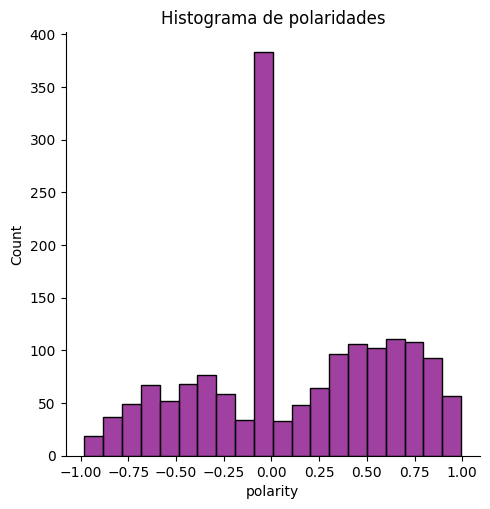

In [ ]:
sns.displot (data = reviewsdata['polarity'], kind = 'hist', color = 'purple', bins = 20)
plt.title('Histograma de polaridades')
plt.show()

## Filtramos los años y sus polaridades

### Reseñas 2011

In [ ]:
# Creamos el vector (XC) el cual contiene los limites de los sentimientos.
# Filtrar 2011
R2011 = reviewsdata[reviewsdata['year'] == 2011]

# Límites
XC2011 = np.array([-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1]) # Escala PANAS-t.
nXC2011 = np.zeros(len(XC2011)) # Creamos una lista con 10 campos vacíos, asigna a uno de estos vacíos la clasificación para cada uno de estos vacíos.

for polarity in R2011['polarity'].dropna():
    dist = np.abs(XC2011 - polarity)
    pos = np.argmin(dist)

    nXC2011[pos] += 1

# cerrar
valores2011 = np.append(nXC2011, nXC2011[0])

# normalizar (evitar división por 0)
if valores2011.sum() > 0:
    valores2011 = valores2011 / valores2011.sum()
valores2011

array([0.        , 0.06930693, 0.06930693, 0.0990099 , 0.27722772,
       0.05940594, 0.08910891, 0.17821782, 0.12871287, 0.02970297,
       0.        ])

In [ ]:
# Verificamos que esté correctamente ejecutado y no estemos perdiendo datos (rows = total filas)
print("Total filas:", len(R2011))
print("Total filas:", len(R2011))
print("No NaN:", R2011['polarity'].notna().sum())
print("Conteo bins:", nXC2011)
print("Suma bins:", nXC2011.sum())

Total filas: 101
Total filas: 101
No NaN: 101
Conteo bins: [ 0.  7.  7. 10. 28.  6.  9. 18. 13.  3.]
Suma bins: 101.0


### Reseñas 2015

In [ ]:
# Filtrar 2015
R2015 = reviewsdata[reviewsdata['year'] == 2015]

# Límites
XC2015 = np.array([-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1]) # Escala PANAS-t.
nXC2015 = np.zeros(len(XC2015)) # Creamos una lista con 10 campos vacíos, asigna a uno de estos vacíos la clasificación para cada uno de estos vacíos.

for polarity in R2015['polarity'].dropna():
    dist = np.abs(XC2015 - polarity)
    pos = np.argmin(dist)

    nXC2015[pos] += 1

# cerrar
valores2015 = np.append(nXC2015, nXC2015[0])

# normalizar (evitar división por 0)
if valores2015.sum() > 0:
    valores2015 = valores2015 / valores2015.sum()
valores2015

array([0.        , 0.03289474, 0.03947368, 0.13157895, 0.27631579,
       0.03289474, 0.15789474, 0.15789474, 0.11842105, 0.05263158,
       0.        ])

In [ ]:
# Verificamos que esté correctamente ejecutado y no estemos perdiendo datos (rows = total filas)
print("Total filas:", len(R2015))
print("No NaN:", R2015['polarity'].notna().sum())
print("Conteo bins:", nXC2015)
print("Suma bins:", nXC2015.sum())

Total filas: 152
No NaN: 152
Conteo bins: [ 0.  5.  6. 20. 42.  5. 24. 24. 18.  8.]
Suma bins: 152.0


### Reseñas 2019

In [ ]:
# Filtrar 2019
R2019 = reviewsdata[reviewsdata['year'] == 2019]

# Límites
XC2019 = np.array([-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1]) # Escala PANAS-t.
nXC2019 = np.zeros(len(XC2019)) # Creamos una lista con 10 campos vacíos, asigna a uno de estos vacíos la clasificación para cada uno de estos vacíos.

for polarity in R2019['polarity'].dropna():
    dist = np.abs(XC2019 - polarity)
    pos = np.argmin(dist)

    nXC2019[pos] += 1

# cerrar
valores2019 = np.append(nXC2019, nXC2019[0])

# normalizar (evitar división por 0)
if valores2019.sum() > 0:
    valores2019 = valores2019 / valores2019.sum()
valores2019

array([0.0304878 , 0.08231707, 0.09146341, 0.0945122 , 0.20731707,
       0.05182927, 0.125     , 0.0945122 , 0.14939024, 0.04268293,
       0.0304878 ])

In [ ]:
# Verificamos que esté correctamente ejecutado y no estemos perdiendo datos (rows = total filas)
print("Total filas:", len(R2019))
print("No NaN:", R2019['polarity'].notna().sum())
print("Conteo bins:", nXC2019)
print("Suma bins:", nXC2019.sum())

Total filas: 318
No NaN: 318
Conteo bins: [10. 27. 30. 31. 68. 17. 41. 31. 49. 14.]
Suma bins: 318.0


### Reseñas 2020

In [ ]:
# Filtrar 2020
R2020 = reviewsdata[reviewsdata['year'] == 2020]

# Límites
XC2020 = np.array([-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1]) # Escala PANAS-t.
nXC2020 = np.zeros(len(XC2020)) # Creamos una lista con 10 campos vacíos, asigna a uno de estos vacíos la clasificación para cada uno de estos vacíos.

for polarity in R2020['polarity'].dropna():
    dist = np.abs(nXC2020 - polarity)
    pos = np.argmin(dist)

    nXC2020[pos] += 1

# cerrar
valores2020 = np.append(nXC2020, nXC2020[0])

# normalizar (evitar división por 0)
if valores2020.sum() > 0:
    valores2020 = valores2020 / valores2020.sum()
valores2020

array([0.18181818, 0.18181818, 0.18181818, 0.09090909, 0.09090909,
       0.09090909, 0.        , 0.        , 0.        , 0.        ,
       0.18181818])

In [ ]:
print("Total filas:", len(R2020))
print("No NaN:", R2020['polarity'].notna().sum())
print("Conteo bins:", nXC2020)
print("Suma bins:", nXC2020.sum())

Total filas: 9
No NaN: 9
Conteo bins: [2. 2. 2. 1. 1. 1. 0. 0. 0. 0.]
Suma bins: 9.0


In [ ]:
# Al ser una gráfica polar, definimos 'theta' como la variable independiente de una función polar. Debemos definir un límite de valores que queremos que se grafiquen
#  En este caso los límites van desde 0 hasta 2 PI
# theta = np.linspace(2* np.pi, 10)
# r = np.cos(3 * theta)

angles = np.linspace(0, 2*np.pi, 10, endpoint = False) # Divido el circulo en 11.
angles = np.concatenate((angles, [angles[0]]))
labels = ['Molesto', 'Irritado', 'Decepcionado', 'Indiferente', 'Neutral', 'Tranquilo',
'Interesado', 'Satisfecho', 'Inspirado', 'Fascinado']

## 3.4 - Gráfico polar

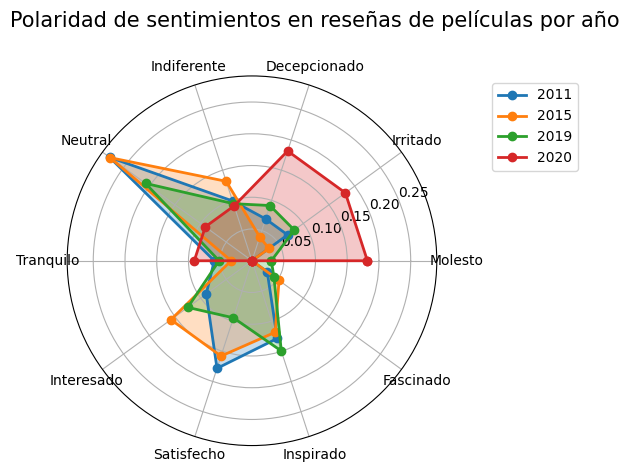

In [ ]:
plt.polar(angles, valores2011, 'o-', linewidth = 2)
plt.polar(angles, valores2015, 'o-', linewidth = 2)
plt.polar(angles, valores2019, 'o-', linewidth = 2)
plt.polar(angles, valores2020, 'o-', linewidth = 2)
plt.fill(angles, valores2011, alpha = 0.25)
plt.fill(angles, valores2015, alpha = 0.25)
plt.fill(angles, valores2019, alpha = 0.25)
plt.fill(angles, valores2020, alpha = 0.25)


plt.thetagrids(angles[:-1]*180/np.pi, labels)
plt.legend(['2011', '2015', '2019', '2020'], bbox_to_anchor = (1.4, 1))
plt.title('Polaridad de sentimientos en reseñas de películas por año', x = 0.67, y = 1.11, fontsize = 15)
plt.show()

# B - MODELOS NEURONALES

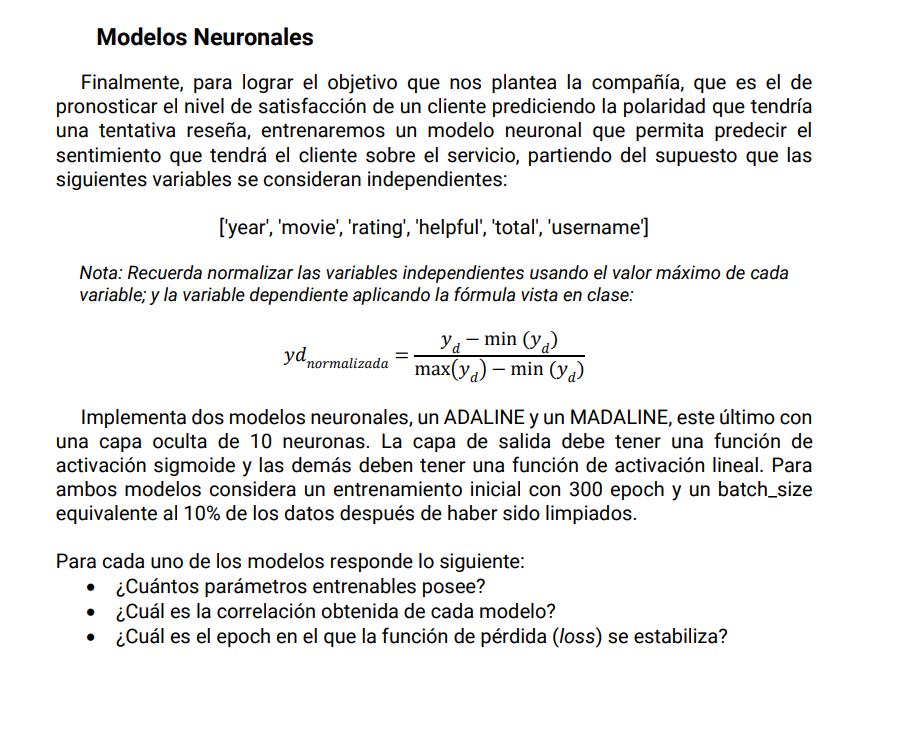

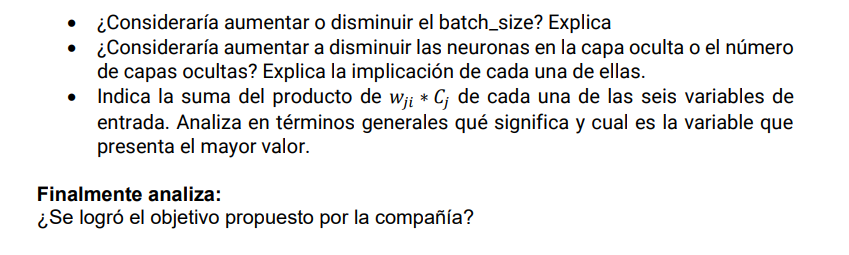

- Podemos ver que contamos con 6 parámetros para el modelo ADALINE y MADAline, esto se debe a que ambos modelos cuentan con la misma cantidad de variables independientes, las cuales son aquellas que denotan la cantidad de paramétros entrenables para modelos como lo son ADALINE o MADALINE

- La correlación obtenida en el modelo ADALINE es de 0.051105, en MADALINE la correlación aumenta a 0.052601

- En ADALINE la función de pérdida se estabiliza en las iteraciones finales. En MADALINE, se estabiliza en la iteración 7/300

- Considero que se puede aumentar el batch_size especialmente para el modelo ADALINE ya que permitiría ver si es un factor que haga que se estabilice el error en la función de pérdida. Caso que no sucede en el modelo MADALINE

- Aumentaría capas ocultas en lugar de neuronas ya que considero que es mejor que la red neuronal aprenda patrones que permitan clasificar correctamente teniendo en cuenta la multicorrelación entre variables

- La suma del producto de 𝑤𝑗𝑖 ∗ 𝐶𝑗, indica la contribución de cada variable al resultado final. La que cuenta con mayor valor es la variable / parámetro de entrenamiento 'movie'.

## Creamos variables independientes y pronóstico

In [ ]:
# Definimos las variables independientes como nos solicita la rúbrica
XD = reviewsdata[['year', 'movie', 'rating', 'helpful', 'total', 'username']]
XD

,year,movie,rating,helpful,total,username
0,2016,0,9.0,3,4,0
1,2016,0,10.0,1,4,1
2,2016,0,8.0,0,4,2
3,2016,0,7.0,0,3,3
4,2018,1,10.0,20,44,4
...,...,...,...,...,...,...
1659,2016,310,10.0,2,4,1605
1660,2016,311,10.0,15,33,1606
1661,2016,311,10.0,3,5,1607
1662,2016,311,9.0,1,1,1608


In [ ]:
# Usamos la columna 'polarity' para así completar nuestros parámetros de entrenamiento y pronosticar la polaridad de una reseña
yd = reviewsdata[['polarity']]
yd

,polarity
0,0.6369
1,0.9299
2,0.2748
3,0.7269
4,0.9381
...,...
1659,0.0000
1660,0.0000
1661,-0.2960
1662,-0.5106


## Limpiamos los datos y normalizamos las variables (XD, yd)

In [ ]:
# Debemos limpiar los datos ya que hasta ahora son un tipo de dato 'dataframe' y no podemos operarlos:
XD = np.array(XD)
yd = np.array(yd)
XD, yd
# Nos damos cuenta que los datos ya no son 'dataframes' ya que aparecen como 'lista de valores en matriz'.

(array([[2.016e+03, 0.000e+00, 9.000e+00, 3.000e+00, 4.000e+00, 0.000e+00],
        [2.016e+03, 0.000e+00, 1.000e+01, 1.000e+00, 4.000e+00, 1.000e+00],
        [2.016e+03, 0.000e+00, 8.000e+00, 0.000e+00, 4.000e+00, 2.000e+00],
        ...,
        [2.016e+03, 3.110e+02, 1.000e+01, 3.000e+00, 5.000e+00, 1.607e+03],
        [2.016e+03, 3.110e+02, 9.000e+00, 1.000e+00, 1.000e+00, 1.608e+03],
        [2.016e+03, 3.110e+02, 8.000e+00, 0.000e+00, 0.000e+00, 1.609e+03]]),
 array([[ 0.6369],
        [ 0.9299],
        [ 0.2748],
        ...,
        [-0.296 ],
        [-0.5106],
        [-0.7357]]))

In [ ]:
# Para esto normalizamos las variables independientes separadas de la variable pronóstico:
XDn = XD/np.max(XD, axis = 0) # Hacemos esto para obtener valores de 0 o 1. Indicamos que haga la ponderación por columnas, es por esto que usamos el comando 'axis = 0'.
ydn = (1/(np.max(yd)-np.min(yd))) * (yd-np.min(yd))
XDn, ydn

(array([[9.83894583e-01, 0.00000000e+00, 9.00000000e-01, 5.16351119e-03,
         3.39847069e-03, 0.00000000e+00],
        [9.83894583e-01, 0.00000000e+00, 1.00000000e+00, 1.72117040e-03,
         3.39847069e-03, 6.21504040e-04],
        [9.83894583e-01, 0.00000000e+00, 8.00000000e-01, 0.00000000e+00,
         3.39847069e-03, 1.24300808e-03],
        ...,
        [9.83894583e-01, 1.00000000e+00, 1.00000000e+00, 5.16351119e-03,
         4.24808836e-03, 9.98756992e-01],
        [9.83894583e-01, 1.00000000e+00, 9.00000000e-01, 1.72117040e-03,
         8.49617672e-04, 9.99378496e-01],
        [9.83894583e-01, 1.00000000e+00, 8.00000000e-01, 0.00000000e+00,
         0.00000000e+00, 1.00000000e+00]]),
 array([[0.81896464],
        [0.96737919],
        [0.63554858],
        ...,
        [0.3464188 ],
        [0.23771654],
        [0.12369567]]))

# 4 - ADALINE (Adaptive Linear)

## Diseñamos el modelo

In [ ]:
# Implementamos el modelo teniendo en cuenta el número de capas y el número de valores de entrada (XD).
# En este caso tenemos 6 variables.
NE_ADALINE = 6 # Número de entradas (Depende de la cantidad de variables independientes).
ADALINE = Sequential() # Acá alojaremos los cortex cerebralex.

# CAPA 1
ADALINE.add(Dense(1, activation = 'linear', use_bias = False, input_dim = NE_ADALINE )) # Definimos la linearidad del modelo, la NO existencia de sesgo y la cantidad de capas.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ADALINE.compile(optimizer = 'adagrad', loss = 'mse') # El modelo 'adagrad' es un modelo de gradiente adaptativo; para la función de pérdida usamos el error cuadrático medio = mse (mean squared error).}
ADALINE.summary() # Para visualizar el modelo.
# Vemos que la cantidad de parámetros entrables coinciden con las 'X' de entrada.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

## Entrenamos el modelo

In [ ]:
historicalADALINE = ADALINE.fit(XDn, ydn, epochs = 300, batch_size = int(len(XDn) * 0.10)) # la variable 'history' va a almacenar el histórico de la forma en la que se entrena el módelo.
# Adicionalmente como tercer parámetro, definimos las iteraciones (epochs) y el "batch_size" sugerido.
# Las iteraciones se hacen con el fin de gradualmente disminuir el error del módelo

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5146
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5016
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4933  
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4867
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4809  
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4759 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4715  
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4674  
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4635  
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4597 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4562 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4530 
Epoch 13/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4499 
Epoch 14/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4468
Epoch 15/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

## Predecimos

In [ ]:
# Ahora veremos qué tan bien predice el modelo (ydPred en otros modelos)
ysADALINE = ADALINE.predict(XDn)
ysADALINE

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.6562593 ],
       [0.68987566],
       [0.62211126],
       ...,
       [1.3779024 ],
       [1.3422095 ],
       [1.3079269 ]], dtype=float32)

## Comparamos

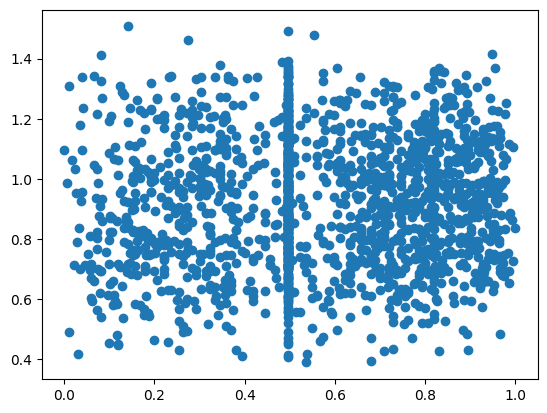

In [ ]:
# Al ser este un modelo de regresión, hacemos una verificación donde comparamos los valores deseados frente a los valores predichos:
# Creamos un scatter plot para comparar yd(valores deseados) con ys (valores predichos)
plt.figure()
plt.scatter(ydn, ysADALINE) # En eje "X" tenemos los valores de yd normalizados vs en el eje "Y" donde graficamos las "Y" predichas en base a los parámetros de entrenamiento normalizados (XDn)
plt.show()

# Realmente vemos una disperción entre 'yr' y 'yd' donde no encontramos una correlación clara.

## Creamos matriz de correlación y pesos (W) / Efectos independientes

In [ ]:
# Matriz de correlación:
mcADALINE = pd.DataFrame(np.column_stack((ydn,ysADALINE)))
mcADALINE.corr()
# De nuevo vemos cifras de correlación bajas mostrando una baja sensibilidad de correlación entre ambas variables.

,0,1
0,1.000000,0.051105
1,0.051105,1.000000


In [ ]:
# Obtenemos los pesos (W) / efectos independientes
W_ADALINE = ADALINE.layers[0].get_weights()
W_ADALINE

[array([[0.35484293],
        [0.3360234 ],
        [0.33872783],
        [0.13798015],
        [0.46011862],
        [0.3517932 ]], dtype=float32)]

# RESETEO DE MEMORIA

### Al modelo ADALINE le podemos hacer una modificación al cambiar el optimizador del modelo. Para esto debemos borrar la memoria del Colab

**Ya no usamos el optimizer = adagrad, sino que utilizamos el optimizer = adam (adaptative multiple)**

In [ ]:
# Borramos la memoria del Colab, se ejecuta una vez ya entrenamos el modelo dentro de la sesión de Colab:
K.clear_session()

# Definimos las semillas para el entrenamiento
seedValue = 42
np.random.seed(seedValue)
tf.random.set_seed(seedValue)
random.seed(seedValue)

del ADALINE

# 5 -  MADALINE (Multi-Adaptive Linear)

## Diseñamos el modelo

In [ ]:
# Implementamos el modelo teniendo en cuenta el número de capas y el número de valores de entrada (XD).
# En este caso tenemos 6 variables.
NE_MADALINE = 6 # Número de entradas (Depende de la cantidad de variables independientes).
MADALINE = Sequential() # Acá alojaremos los cortex cerebralex.

# CAPA 1
MADALINE.add(Dense(10, activation = 'linear', use_bias = False, input_dim = NE_MADALINE )) # Definimos la cantidad de capas, la linearidad del modelo y la NO existencia de sesgo

# CAPA 2
MADALINE.add(Dense(1, activation='sigmoid', use_bias=False))

MADALINE.compile(optimizer = 'adam', loss = 'mse')
MADALINE.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70 (280.00 B)

 Trainable params: 70 (280.00 B)

 Non-trainable params: 0 (0.00 B)

## Entrenamos el modelo

In [ ]:
historicalMADALINE = MADALINE.fit(XDn, ydn, epochs = 300, batch_size = int(len(XDn) * 0.10)) # la variable 'history' va a almacenar el histórico de la forma en la que se entrena el módelo.
# Adicionalmente como tercer parámetro, definimos las iteraciones (epochs) y el "batch_size" sugerido.
# Las iteraciones se hacen con el fin de gradualmente disminuir el error del módelo

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0636  
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0630 
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0627 
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0626 
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0624 
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0623 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0622 
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0622 
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 
Epoch 13/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 
Epoch 14/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 
Epoch 15/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

## Predecimos

In [ ]:
# Ahora veremos qué tan bien predice el modelo (ydPred en otros modelos)
ys_MADALINE = MADALINE.predict(XDn)
ys_MADALINE

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.5107488 ],
       [0.50774723],
       [0.5135758 ],
       ...,
       [0.59287924],
       [0.5956515 ],
       [0.5984351 ]], dtype=float32)

## Comparamos

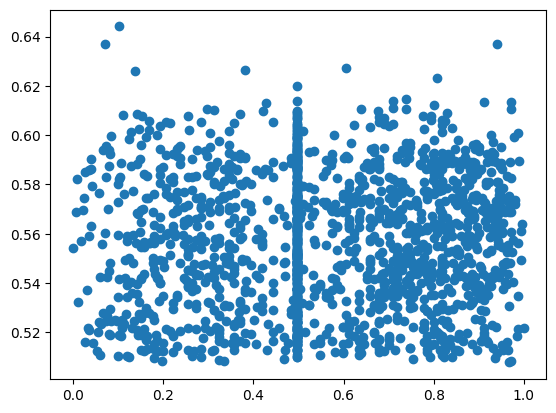

In [ ]:
# Al ser este un modelo de regresión, hacemos una verificación donde comparamos los valores deseados frente a los valores predichos:
# Creamos un scatter plot para comparar yd(valores deseados) con ys (valores predichos)
plt.figure()
plt.scatter(ydn, ys_MADALINE)
plt.show()

## Creamos matriz de correlación y pesos (W) / Efectos independientes

In [ ]:
# Creamos una matriz de correlación:
df = pd.DataFrame(np.column_stack((ydn,ys_MADALINE)))
df.corr()

,0,1
0,1.000000,0.052601
1,0.052601,1.000000


In [ ]:
# Obtenemos los pesos (W) / efectos independientes
W1_MADALINE = MADALINE.layers[0].get_weights() # Capa 1 (Array [0])
W1_MADALINE

[array([[ 0.41886324,  0.21912949, -0.19375405,  0.53070766, -0.5364994 ,
          0.20621227,  0.555797  , -0.40105307,  0.04975378,  0.1816332 ],
        [-0.33061492, -0.27475148,  0.7529327 ,  0.1459368 ,  0.17269896,
          0.1529142 , -0.42362872, -0.22076036, -0.15946427, -0.7085814 ],
        [-0.6340241 ,  0.504419  ,  0.44000444, -0.35951138,  0.37394473,
         -0.38988712, -0.1119999 ,  0.03915474,  0.1505269 , -0.2975551 ],
        [-0.18287024,  0.3978246 , -0.29862493,  0.11003757, -0.1215122 ,
         -0.633841  ,  0.4484609 , -0.23574853,  0.04864781,  0.01004574],
        [-0.52900714,  0.03437325, -0.18127912, -0.11480194,  0.588807  ,
         -0.13656718,  0.06557822, -0.2648214 , -0.4936482 ,  0.23427084],
        [ 0.10610343,  0.04981217, -0.6235743 , -0.5105071 ,  0.32444   ,
          0.48523515, -0.11816655, -0.23124109, -0.5349885 , -0.52628577]],
       dtype=float32)]

In [ ]:
W2_MADALINE = MADALINE.layers[1].get_weights() # Capa 2 (Array [1])
W2_MADALINE

[array([[ 0.6775523 ],
        [-0.09606067],
        [ 0.5658433 ],
        [ 0.49732906],
        [ 0.33804196],
        [-0.48645255],
        [ 0.19635148],
        [ 0.01086868],
        [-0.64745176],
        [-0.31345907]], dtype=float32)]

In [ ]:
W1 = MADALINE.layers[0].get_weights()[0]
W2 = MADALINE.layers[1].get_weights()[0]

contribucion = np.abs(W1 @ W2).flatten()

variables = ['year', 'movie', 'rating', 'helpful', 'total', 'username']

for var, val in zip(variables, contribucion):
    print(f"{var}: {val:.4f}")

print(f"\nMayor contribución: {variables[np.argmax(contribucion)]}")

year: 0.1510
movie: 0.5248
rating: 0.1175
helpful: 0.0417
total: 0.0003
username: 0.1804

Mayor contribución: movie
